# NIMROD Rainfall Viewer

Visualises the output of `scripts/test_nimrod_rainfall.py` for a saved Sample.

**Run the script first:**
```bash
python -m scripts.test_nimrod_rainfall 1
```
Then set `SAMPLE_INDEX` below to match.

---
### Contents
1. Imports & config
2. Load sample
3. Rainfall summary & time-series
4. Interactive map — mean & max rainfall overlays

## 1 — Imports & config

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import branca.colormap as cm
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eoflow.folium import make_base_map_from_poly, make_raster_overlay
from eoflow.samples import Sample
from eoflow.utils import DATA_DIR

warnings.filterwarnings("ignore")

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
SAMPLE_INDEX = 9   # must match the index passed to test_nimrod_rainfall.py

SAMPLE_DIR = DATA_DIR / f"sample_instances/sample_{SAMPLE_INDEX:03d}_nimrod_test"

assert SAMPLE_DIR.exists(), f"Sample not found: {SAMPLE_DIR}\nRun: python -m scripts.test_nimrod_rainfall {SAMPLE_INDEX}"
print("Loading from:", SAMPLE_DIR)

Loading from: /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/sample_instances/sample_009_nimrod_test


## 2 — Load sample

In [4]:
sample = Sample.load(SAMPLE_DIR)

print(f"Site      : {sample.site_name}")
print(f"Notation  : {sample.notation}")
print(f"Catchment : {'yes' if sample.has_catchment else 'NO'}")

da = sample.layers.rainfall
assert da is not None and da.size > 0, "No rainfall layer found in saved sample."

print(f"\nRainfall array")
print(f"  Shape     : {dict(da.sizes)}")
print(f"  Time range: {str(da.time.values[0])[:19]}  →  {str(da.time.values[-1])[:19]}")
print(f"  Units     : {da.attrs.get('units', 'mm/h')}")

2026-06-10 16:14:23,302 - eoflow.samples - DEBUG - Loaded metadata from /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/sample_instances/sample_009_nimrod_test/metadata.json
2026-06-10 16:14:23,305 - eoflow.samples - DEBUG - Loaded catchment geometry from /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/sample_instances/sample_009_nimrod_test/catchment.wkt
2026-06-10 16:14:23,305 - eoflow.samples - DEBUG - Loaded catchment geometry from /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/sample_instances/sample_009_nimrod_test/catchment.wkt
2026-06-10 16:14:23,332 - eoflow.samples - DEBUG - Loaded topography layer from /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/sample_instances/sample_009_nimrod_test/layers/topography.nc
2026-06-10 16:14:23,336 - eoflow.samples - DEBUG - Loaded slope layer from /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/sample_instances/sample_009_nimrod_test/layers/slope.nc
2026-06-10 16:14:23,345 - eoflow.samples - DE

## 3 — Rainfall summary & time-series

In [6]:
# Spatially averaged rainfall rate at each timestep
ts = da.mean(dim=["x", "y"], skipna=True).to_pandas()
ts.index = pd.to_datetime(ts.index)

print("Summary (mm/h):")
print(f"  Min  : {float(da.min(skipna=True)):.4f}")
print(f"  Max  : {float(da.max(skipna=True)):.4f}")
print(f"  Mean : {float(da.mean(skipna=True)):.4f}")
print(f"  Wet timesteps (mean > 0): {int((ts > 0).sum())} / {len(ts)}")

Summary (mm/h):
  Min  : 0.0000
  Max  : 54.3125
  Mean : 0.1343
  Wet timesteps (mean > 0): 3295 / 12523


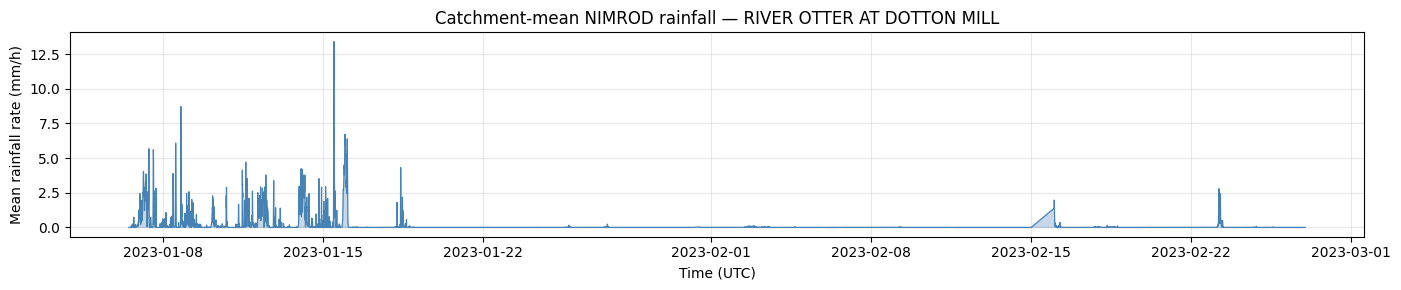

In [7]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(ts.index, ts.values, lw=0.8, color="steelblue")
ax.fill_between(ts.index, ts.values, alpha=0.3, color="steelblue")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Mean rainfall rate (mm/h)")
ax.set_title(f"Catchment-mean NIMROD rainfall — {sample.site_name}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4 — Interactive map

Toggleable overlays:
- **Mean rainfall** — time-averaged rate across all timesteps
- **Peak rainfall** — maximum rate recorded at each pixel
- **Catchment boundary** — the delineated watershed polygon
- **Sample point** — the EA monitoring location

In [ ]:
# ── Compute 2-D summary layers ────────────────────────────────────────────────
da_mean = da.mean(dim="time", skipna=True)
da_peak = da.max(dim="time", skipna=True)

# Shared colour scale across both layers so they are directly comparable
vmin = 0.0
vmax = float(np.nanpercentile(da_peak.values, 98))
vmax = max(vmax, 0.01)   # avoid zero-range if all dry

print(f"Colour scale: {vmin:.3f} – {vmax:.3f} mm/h")

Colour scale: 0.000 – 50.175 mm/h


In [ ]:
# ── Base map centred on the catchment ─────────────────────────────────────────
m = make_base_map_from_poly(sample.catchment)

# ── Rainfall raster overlays ──────────────────────────────────────────────────
make_raster_overlay(
    da_mean, cmap="YlOrRd", vmin=vmin, vmax=vmax,
    label="Mean rainfall (mm/h)", alpha=0.7,
).add_to(m)

make_raster_overlay(
    da_peak, cmap="YlOrRd", vmin=vmin, vmax=vmax,
    label="Peak rainfall (mm/h)", alpha=0.7,
).add_to(m)

# ── Catchment boundary ────────────────────────────────────────────────────────
folium.GeoJson(
    sample.catchment_geojson(),
    name="Catchment",
    style_function=lambda _: {
        "color": "#2471a3", "weight": 2, "fillOpacity": 0.05,
    },
    tooltip="Catchment boundary",
).add_to(m)

# ── Sample point ──────────────────────────────────────────────────────────────
folium.CircleMarker(
    location=[sample.latitude, sample.longitude],
    radius=7, color="#c0392b", fill=True, fill_opacity=0.9,
    tooltip=f"{sample.site_name}",
).add_to(m)

# ── Legend ────────────────────────────────────────────────────────────────────
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=vmin, vmax=vmax,
    caption="Rainfall rate (mm/h)",
)
colormap.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

In [35]:
print(sample.layers.ndvi.shape)

(11, 2478, 1988)


In [9]:
sample.layers


CatchmentLayers(computed=['topography', 'slope', 'aspect', 'soil_type', 'soil_polygons', 'rainfall', 'ndvi', 'ndwi', 'eo_bands'])

In [10]:
print(sample.layers.ndwi.shape)

(11, 2478, 1988)


In [14]:
import matplotlib.pyplot as plt

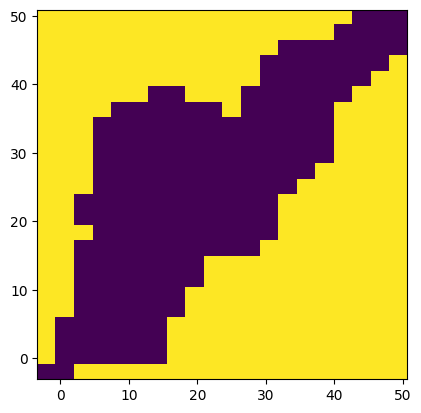

In [32]:
lon_min, lon_max, lat_min, lat_max = sample.catchment_bbox()

step = 0
nanmap = np.isnan(da[step])

plt.imshow(nanmap, extent=[lon_min, lon_max, lat_min, lat_max], origin='lower')

In [33]:
sample._spatial_extent_dict()

{'west': -3.3587500111111064,
 'south': 50.68402778888889,
 'east': -3.0779166777777727,
 'north': 50.90625001111111}

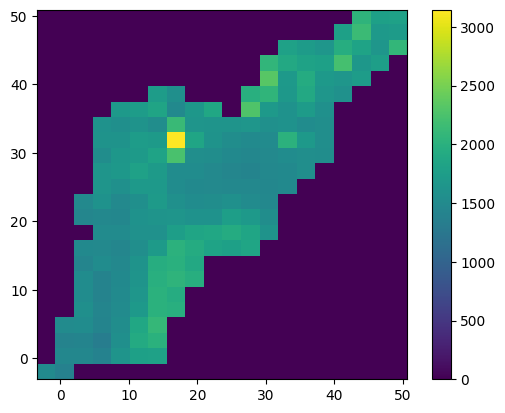

In [34]:
total_rain = np.nansum(da, axis=0)
plt.figure()
plt.imshow(total_rain, extent=[lon_min, lon_max, lat_min, lat_max], origin='lower')
plt.colorbar()

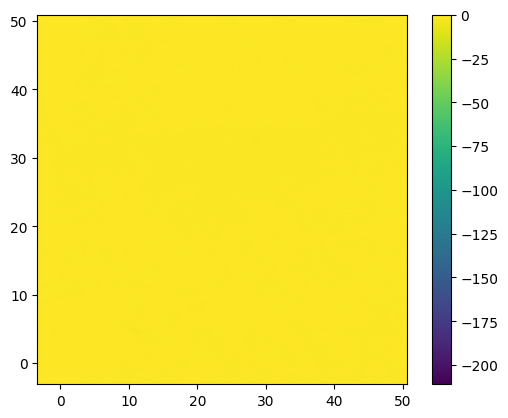

In [41]:

ndvi_mean = np.nanmin(sample.layers.ndwi, axis=0)
plt.figure()
plt.imshow(ndvi_mean, extent=[lon_min, lon_max, lat_min, lat_max], origin='lower')
plt.colorbar()

In [84]:
sample.layers.ndvi.shape

(11, 2478, 1988)

In [91]:
sample.date

datetime.date(2020, 1, 14)

In [103]:
a= [layer.t for layer in sample.layers.ndvi]
a[0]

<xarray.DataArray 't' ()> Size: 8B
array('2024-02-10T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    t        datetime64[ns] 8B 2024-02-10
Attributes:
    standard_name:  t
    long_name:      t
    axis:           T

In [114]:
sample.date

datetime.date(2020, 1, 14)

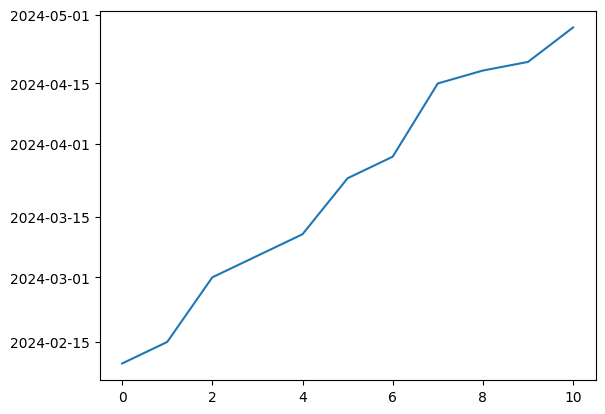

In [ ]:
plt.plot(sample.layers.ndvi.t)

In [116]:
sample.layers.ndwi.t

<xarray.DataArray 't' (t: 11)> Size: 88B
array(['2024-02-10T00:00:00.000000000', '2024-02-15T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000', '2024-03-06T00:00:00.000000000',
       '2024-03-11T00:00:00.000000000', '2024-03-24T00:00:00.000000000',
       '2024-03-29T00:00:00.000000000', '2024-04-15T00:00:00.000000000',
       '2024-04-18T00:00:00.000000000', '2024-04-20T00:00:00.000000000',
       '2024-04-28T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 88B 2024-02-10 2024-02-15 ... 2024-04-28
Attributes:
    standard_name:  t
    long_name:      t
    axis:           T

In [97]:
layer = sample.layers.ndvi[0]
type(layer)
layer.t

<xarray.DataArray 't' ()> Size: 8B
array('2024-02-10T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    t        datetime64[ns] 8B 2024-02-10
Attributes:
    standard_name:  t
    long_name:      t
    axis:           T

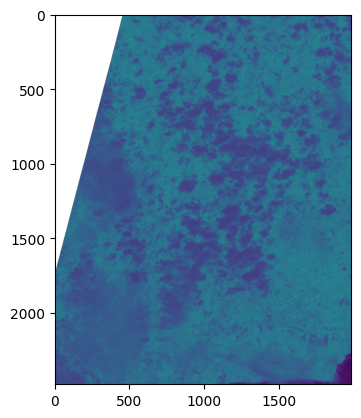

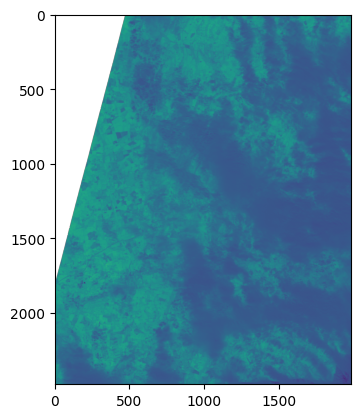

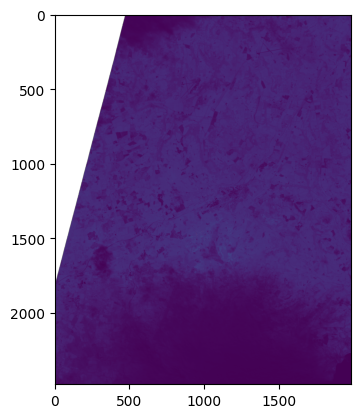

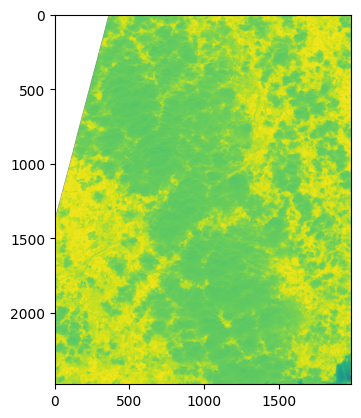

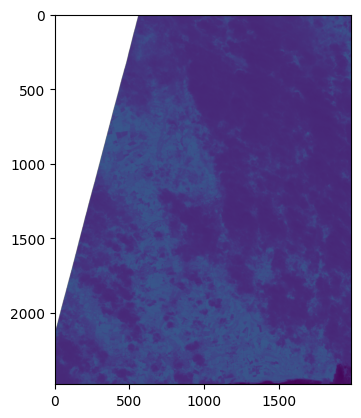

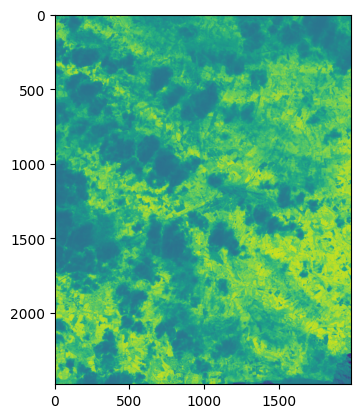

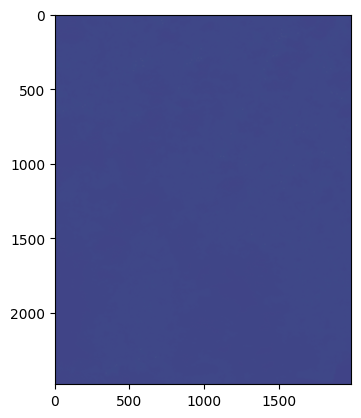

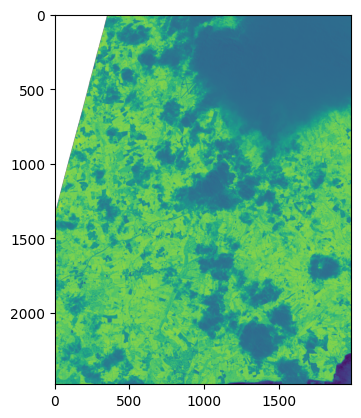

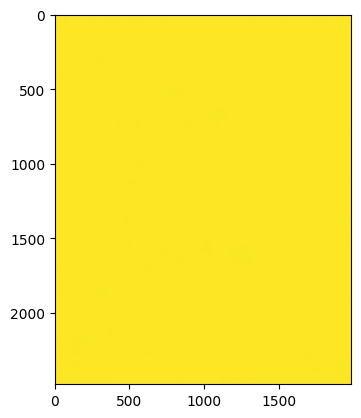

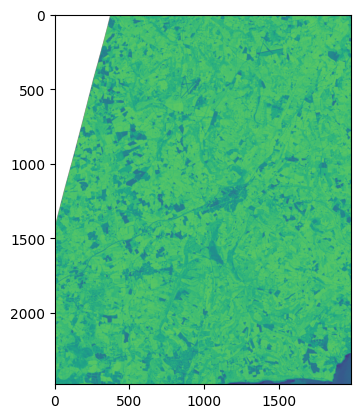

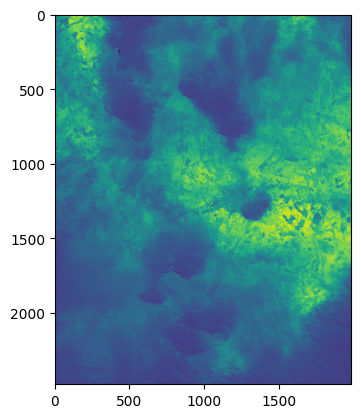

In [86]:
for i in range(11):
    plt.figure()
    ndvi_step = np.asarray(sample.layers.ndvi[i])
    plt.imshow(ndvi_step*505)
    ndvi_step.max()

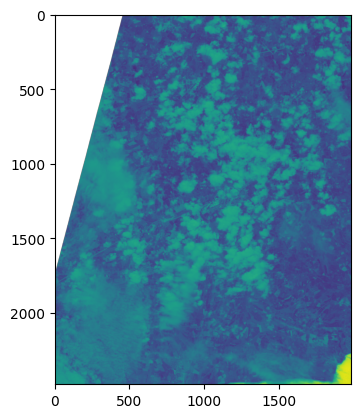

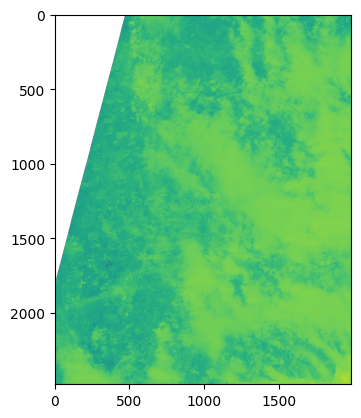

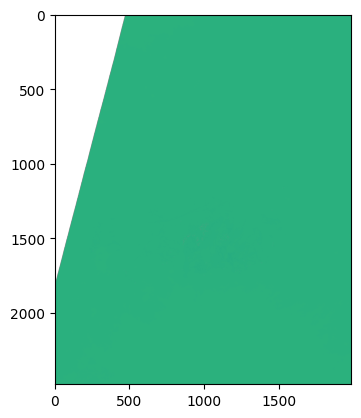

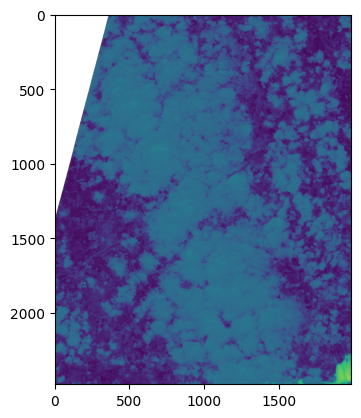

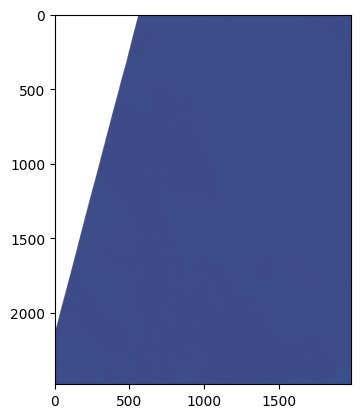

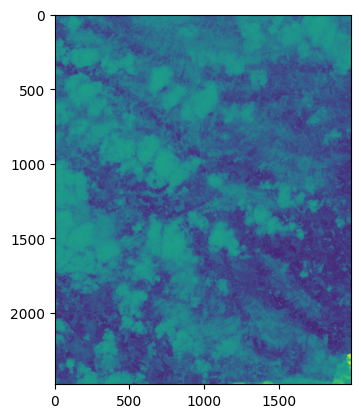

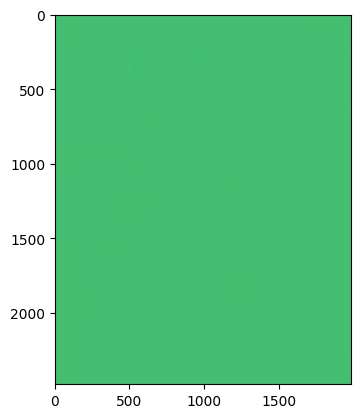

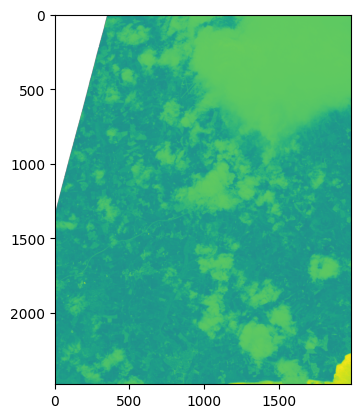

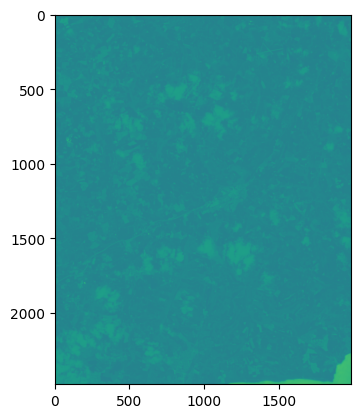

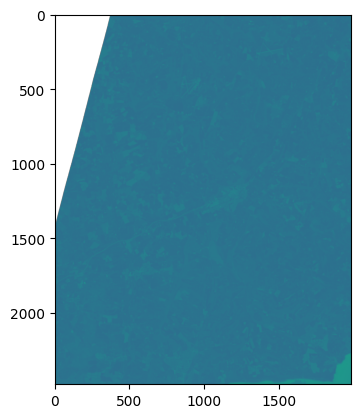

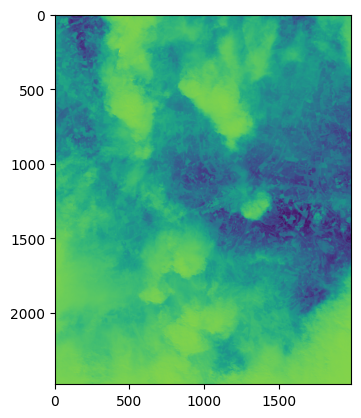

In [87]:

for i in range(11):
    plt.figure()
    ndvi_step = np.asarray(sample.layers.ndwi[i])
    plt.imshow(ndvi_step*505)
    ndvi_step.max()

In [72]:

# plt.hist(clean, bins=30)
# plt.show()

np.where((~np.isnan(ndvi_step)))

(array([   0,    0,    0, ..., 2477, 2477, 2477], shape=(4497624,)),
 array([ 471,  472,  473, ..., 1985, 1986, 1987], shape=(4497624,)))

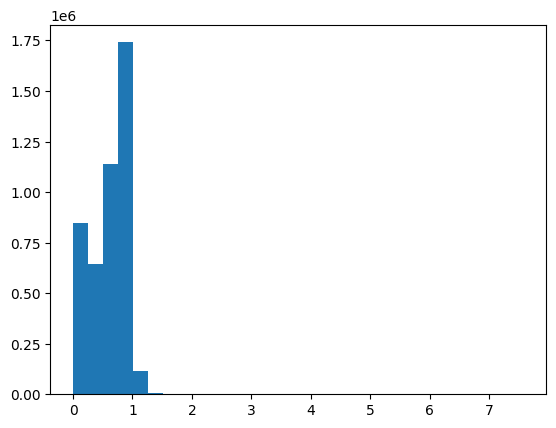

In [76]:
arr = np.asarray(ndvi_step)
arr[arr<0] = 0 
clean = arr.ravel()
clean = clean[~np.isnan(clean)]

plt.hist(clean, bins=30)
plt.show()

In [75]:
ndvi_step.min()

<xarray.DataArray 'ndvi' ()> Size: 4B
array(-30.39535, dtype=float32)
Coordinates:
    t        datetime64[ns] 8B 2024-03-01